# Assessing context duplication in QuAnTS

The *context* of a QuAnTS sample is the multivariate trajectory a question is asked about: the
`trajectory` column of the published dataset, shape `(320, 24, 3)` — 16 s at 20 FPS, 24 SMPL joints,
xyz. Length and channel count are constant across the dataset.

This notebook measures how much of that is redundant, at two levels:

1. **Signal level** — how many trajectories are near-duplicates of another trajectory, using a
   scale-free per-channel distance, exact k-nearest-neighbour candidate generation, and a
   single-linkage threshold sweep validated against two nulls.
2. **Label level** — how many samples share an identical 4-action sequence, and how many of those
   collisions cross the train/val/test boundary.

## Scope and limitations

**Raw world frame, as-is.** Global translation and heading are *not* removed. Two identical motions
performed at different places or facing different directions count as *different*. Every redundancy
number below is therefore a **lower bound** on motion-pattern redundancy — canonicalising root
position and yaw would only ever merge more samples, never fewer.

**Candidate-based.** The k-NN itself is exact — no approximate index, no recall parameter — but it
ranks candidates by *embedding distance* while the threshold is applied to the *refined score*, and
only the top `knn_k` neighbours per sample are re-scored. A pair outside both samples'
neighbourhoods is invisible to the sweep. This is measured rather than assumed, under *Candidate
recall* below: at the permissive threshold a measurable fraction of the true below-$\tau$ pairs is
missed, so every redundancy figure here is a lower bound.

**Single linkage.** The sweep merges transitively, so above the percolation point the clusters are
chaining artefacts rather than duplicate groups. That region is shaded in the figure and excluded
from interpretation.

## Setup

In [1]:
import hashlib
from collections import defaultdict
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import DatasetDict, VerificationMode, load_dataset
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, minimum_spanning_tree
from tqdm.auto import tqdm

sns.set_context("talk")
sns.set_theme(style="whitegrid")
sns.set_palette("colorblind")

CONFIG = {
    "knn_k": 20,
    "score_quantile": 0.95,
    "seed": 0,
    "n_null_pairs": 100_000,
    "degenerate_std": 1e-6,
    "knn_chunk": 2048,
    "score_batch": 512,
    "percolation_fraction": 0.10,
    "weight_floor": 1e-12,
    "duplicate_sigma": 0.5,
    "n_recall_anchors": 300,
}
rng = np.random.default_rng(CONFIG["seed"])

if not torch.cuda.is_available():
    raise RuntimeError("This notebook requires a CUDA GPU.")
device = torch.device("cuda")
print(f"Using {torch.cuda.get_device_name(0)}")
CONFIG

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using Tesla V100-SXM3-32GB-H


{'knn_k': 20,
 'score_quantile': 0.95,
 'seed': 0,
 'n_null_pairs': 100000,
 'degenerate_std': 1e-06,
 'knn_chunk': 2048,
 'score_batch': 512,
 'percolation_fraction': 0.1,
 'weight_floor': 1e-12,
 'duplicate_sigma': 0.5,
 'n_recall_anchors': 300}

## Loading the contexts

The contexts come from the published dataset on HuggingFace, loaded exactly the way
[dataset-statistics.ipynb](dataset-statistics.ipynb) loads it — except that `trajectory` is the one
column we need, so it is *not* dropped. The first run downloads ~14 GB and caches it; later runs are
fast.

Two things have to be handled that the statistics notebook does not care about:

- **Rows are per question, not per sample.** The same trajectory is repeated once for every QA pair
  it belongs to, and across the three answer-type variants. Contexts are therefore deduplicated by
  `sample_id`, keeping the first occurrence.
- **The split comes from the dataset itself.** `train`/`val`/`test` membership is read off the
  HuggingFace splits, so the leakage analysis needs nothing outside this notebook.

The parquet files are already cached locally by `datasets`, and rebuilding the deduplicated array from
them takes ~20 s, so there is nothing to gain from also caching the 2.8 GB of trajectories ourselves.
The pair scores further down *are* persisted — those cost real compute.

In [2]:
HF_REPO = "dasyd/quants"
VARIANTS = ["binary", "multi", "open"]
SPLITS = ["train", "val", "test"]

out_dir = Path("similarity").absolute()
out_dir.mkdir(exist_ok=True)
out_dir

PosixPath('/workspaces/quants-generate/quants/notebooks/similarity')

In [3]:
def load_contexts():
    "One trajectory per sample_id, plus its action sequence and split."
    variants = DatasetDict({
        variant: load_dataset(
            HF_REPO,
            variant,
            data_dir=variant,
            data_files={split: f"{split}-*" for split in SPLITS},
            verification_mode=VerificationMode.NO_CHECKS,
        )
        for variant in VARIANTS
    })

    # Project away `trajectory` first: arrow is columnar, so deciding which rows are duplicates
    # never touches the 14 GB of trajectories. Action sequences are converted one row at a time,
    # only for the rows actually kept.
    first_occurrence, splits, sequences = {}, {}, {}
    for variant, per_split in variants.items():
        for split, subset in per_split.items():
            light = subset.select_columns(["sample_id", "action_sequence"])
            sample_ids = light.data.column("sample_id").to_pylist()
            actions = light.data.column("action_sequence")
            for position, sample_id in enumerate(sample_ids):
                key = int(sample_id)
                if key not in first_occurrence:
                    first_occurrence[key] = (variant, split, position)
                    splits[key] = split
                    # `action_sequence` is declared Sequence(Features(...)), which arrow stores as
                    # a struct of lists rather than a list of per-step dicts, so the ordered action
                    # names are one field rather than a value per step.
                    sequences[key] = tuple(actions[position].as_py()["action"])

    ordered = sorted(first_occurrence)
    position_of = {key: index for index, key in enumerate(ordered)}
    trajectories = np.empty((len(ordered), 320, 24, 3), dtype=np.float32)

    grouped = defaultdict(list)
    for key, (variant, split, position) in first_occurrence.items():
        grouped[(variant, split)].append((position, position_of[key]))

    for (variant, split), items in tqdm(sorted(grouped.items()), desc="gathering trajectories"):
        items.sort()
        rows = [row for row, _ in items]
        targets = np.array([target for _, target in items])
        selected = variants[variant][split].select(rows).with_format("numpy")
        for start in range(0, len(rows), 512):
            block = selected[start:start + 512]["trajectory"]
            trajectories[targets[start:start + 512]] = block

    return (
        trajectories,
        np.array(ordered),
        [sequences[key] for key in ordered],
        np.array([splits[key] for key in ordered]),
    )

In [4]:
joints, ids, action_sequences, split_of = load_contexts()

print(f"{len(joints)} contexts from {HF_REPO}")
print({split: int((split_of == split).sum()) for split in SPLITS})
joints.shape, joints.dtype, f"{joints.nbytes / 1e9:.2f} GB"

gathering trajectories:   0%|          | 0/9 [00:00<?, ?it/s]

gathering trajectories:  11%|█         | 1/9 [00:01<00:11,  1.40s/it]

gathering trajectories:  22%|██▏       | 2/9 [00:12<00:49,  7.01s/it]

gathering trajectories:  33%|███▎      | 3/9 [00:13<00:26,  4.43s/it]

gathering trajectories:  44%|████▍     | 4/9 [00:13<00:13,  2.73s/it]

gathering trajectories:  56%|█████▌    | 5/9 [00:14<00:08,  2.09s/it]

gathering trajectories:  67%|██████▋   | 6/9 [00:14<00:04,  1.42s/it]

gathering trajectories: 100%|██████████| 9/9 [00:14<00:00,  1.66s/it]

30000 contexts from dasyd/quants
{'train': 24000, 'val': 3000, 'test': 3000}


((30000, 320, 24, 3), dtype('float32'), '2.76 GB')

## Data contract

Everything downstream assumes a constant shape and finite values. Assert it rather than discover it
later as a silently wrong number.

In [5]:
assert joints.ndim == 4 and joints.shape[1:] == (320, 24, 3), joints.shape
assert joints.dtype == np.float32, joints.dtype
assert np.isfinite(joints).all(), "non-finite values in joints"
assert len(action_sequences) == len(joints) == len(ids) == len(split_of)
assert len(set(ids.tolist())) == len(ids), "sample ids are not unique after deduplication"
assert set(split_of) <= set(SPLITS), set(split_of)

# (n, time, channel) with 24 joints x 3 axes flattened into 72 channels
series = np.ascontiguousarray(joints.reshape(len(joints), 320, 72))
n_total, n_time, n_channels = series.shape
del joints

n_total, n_time, n_channels

(30000, 320, 72)

## Degenerate series

A series whose every channel is constant has no scale, so the pooled per-channel denominator of the
pair metric collapses and every distance involving it becomes meaningless. This is the one failure
mode that would corrupt every downstream number, so it is checked explicitly and reported even when
the count is zero.

In [6]:
channel_std = series.std(axis=1)  # (n, 72)
degenerate_mask = (channel_std < CONFIG["degenerate_std"]).all(axis=1)
n_degenerate = int(degenerate_mask.sum())

any_degenerate = int((channel_std < CONFIG["degenerate_std"]).any(axis=1).sum())
print(f"Fully degenerate series (all 72 channels std < {CONFIG['degenerate_std']:g}): {n_degenerate}")
print(f"Series with at least one degenerate channel: {any_degenerate}")
print(f"Smallest per-series maximum channel std: {channel_std.max(axis=1).min():.6f}")

keep = ~degenerate_mask
series = np.ascontiguousarray(series[keep])
ids = ids[keep]
split_of = split_of[keep]
action_sequences = [seq for seq, k in zip(action_sequences, keep) if k]
n = len(series)
print(f"\nAnalysing n = {n} series ({n_degenerate} excluded).")

Fully degenerate series (all 72 channels std < 1e-06): 0
Series with at least one degenerate channel: 0
Smallest per-series maximum channel std: 0.041695



Analysing n = 30000 series (0 excluded).


## Exact duplicates

A cheap first pass before any metric is involved: group bit-identical arrays, and separately group
arrays that agree to 4 decimals. `sha256` is used only to bucket identical byte strings — no
cryptographic property is needed, and every hit is re-verified against the refined distance further
down.

In [7]:
def hash_groups(arrays, decimals=None):
    "Map each digest to the list of row indices producing it."
    groups = defaultdict(list)
    for index, array in enumerate(arrays):
        payload = array if decimals is None else np.round(array, decimals)
        digest = hashlib.sha256(np.ascontiguousarray(payload, np.float32).tobytes()).digest()
        groups[digest].append(index)
    return {digest: rows for digest, rows in groups.items() if len(rows) > 1}


exact_groups = {
    "raw": hash_groups(series),
    "round(4)": hash_groups(series, decimals=4),
}

for mode, groups in exact_groups.items():
    involved = sum(len(rows) for rows in groups.values())
    largest = max((len(rows) for rows in groups.values()), default=0)
    print(f"{mode:>9}: {len(groups)} duplicate groups, {involved} series involved, largest group {largest}")

exact_pairs_raw = {
    tuple(sorted(pair))
    for rows in exact_groups["raw"].values()
    for pair in combinations(rows, 2)
}
len(exact_pairs_raw)

      raw: 0 duplicate groups, 0 series involved, largest group 0
 round(4): 0 duplicate groups, 0 series involved, largest group 0


0

## Embedding for candidate generation

Each channel is divided by its own standard deviation *within that series*, so a channel with a
large dynamic range does not dominate the neighbour search. The result is flattened to one vector
per sample. No dimensionality reduction — the k-NN below is exact, so there is no approximation
error to trade against speed.

Note that the series are **not** centred: a constant offset between two otherwise identical motions
survives into the embedding. That is deliberate and follows from working in the raw world frame.

In [8]:
def make_embedding(source):
    "Per-channel std normalisation, flattened to one C-contiguous float32 vector per series."
    scale = np.maximum(source.std(axis=1, keepdims=True), CONFIG["degenerate_std"])
    return np.ascontiguousarray((source / scale).reshape(len(source), -1), dtype=np.float32)


embedding = make_embedding(series)

assert embedding.shape == (n, n_time * n_channels)
assert embedding.flags["C_CONTIGUOUS"] and np.isfinite(embedding).all()
embedding.shape, f"{embedding.nbytes / 1e9:.2f} GB"

((30000, 23040), '2.76 GB')

## The pair metric

For two series $x, y$ of shape (time, channel):

1. pooled per-channel scale $s_c = \sqrt{(\mathrm{var}(x_c) + \mathrm{var}(y_c)) / 2}$,
2. scaled absolute deviation $|x_{tc} - y_{tc}| / s_c$,
3. the 0.95-quantile over time, per channel,
4. the maximum over channels.

The result is in units of $\sigma$ and is symmetric in $x$ and $y$ — required, since it becomes an
undirected edge weight. Taking a high quantile rather than the maximum over time keeps a handful of
frames of disagreement from vetoing an otherwise identical pair; taking the maximum over channels
means *every* channel must agree for a pair to score low.

There is exactly **one** reduction over channels, the final maximum in step 4. The `SCALE_FLOOR`
applied to $s_c$ in step 1 is an element-wise floor on each channel's own scale — it guards the
division for a channel in which both series are near-constant, and does not combine channels.

A readable numpy version defines the metric; a batched torch version computes it 600 000 times.

In [9]:
# Smallest pooled per-channel scale we are willing to divide by. This is an element-wise floor on
# each channel's scale, NOT a reduction across channels: it only stops a channel whose pooled
# standard deviation is ~0 (both series near-constant in it) from blowing up the ratio. The single
# reduction over channels is the max on the last line of each function below.
SCALE_FLOOR = 1e-8


def pair_score(x, y, q=CONFIG["score_quantile"]):
    "Reference implementation, in units of sigma. x, y: (time, channel)."
    s = np.sqrt((x.var(axis=0, ddof=1) + y.var(axis=0, ddof=1)) / 2)  # (channel,)
    deviation = np.abs(x - y) / np.clip(s, SCALE_FLOOR, None)  # (time, channel)
    per_channel = np.quantile(deviation, q, axis=0)  # quantile over time -> (channel,)
    return float(per_channel.max())  # worst channel


def pair_score_batch(a, b, q=CONFIG["score_quantile"]):
    "Vectorised equivalent. a, b: (batch, time, channel) tensors on the same device."
    s = torch.sqrt((a.var(dim=1, unbiased=True) + b.var(dim=1, unbiased=True)) / 2)  # (batch, channel)
    deviation = (a - b).abs() / s.clamp_min(SCALE_FLOOR)[:, None, :]
    per_channel = torch.quantile(deviation, q, dim=1)  # quantile over time -> (batch, channel)
    return per_channel.amax(dim=1)  # worst channel

In [10]:
# Verification: the metric is symmetric, and the two implementations agree.
check_i = rng.integers(0, n, 100)
check_j = rng.integers(0, n, 100)
forward = np.array([pair_score(series[i], series[j]) for i, j in zip(check_i, check_j)])
backward = np.array([pair_score(series[j], series[i]) for i, j in zip(check_i, check_j)])
assert np.allclose(forward, backward, atol=1e-6), "pair_score is not symmetric"

batched = pair_score_batch(
    torch.from_numpy(series[check_i]), torch.from_numpy(series[check_j])
).numpy()
largest_gap = np.abs(forward - batched).max()
assert np.allclose(forward, batched, atol=1e-4), largest_gap
print(f"Symmetric and consistent on 100 random pairs (max |numpy - torch| = {largest_gap:.2e}).")

Symmetric and consistent on 100 random pairs (max |numpy - torch| = 4.29e-06).


## Candidate generation: exact k-nearest neighbours

Chunked brute-force squared euclidean distance over the whole embedding. This is exact — no index,
no training, no recall parameter. `faiss` would run the identical computation for an exact index,
and only its *approximate* indexes are faster, which would inject recall error into the very
quantity being measured.

In [11]:
def knn_candidates(matrix, k, chunk=CONFIG["knn_chunk"]):
    "Exact k-NN by chunked matmul. Returns (indices, distances), both (n, k)."
    tensor = torch.from_numpy(matrix).to(device)
    square_norm = (tensor**2).sum(1)
    all_indices, all_distances = [], []
    for low in range(0, len(tensor), chunk):
        high = min(low + chunk, len(tensor))
        d2 = square_norm[low:high, None] + square_norm[None, :] - 2 * (tensor[low:high] @ tensor.T)
        d2[torch.arange(high - low, device=device), torch.arange(low, high, device=device)] = float("inf")
        distances, indices = torch.topk(d2, k, dim=1, largest=False)
        all_indices.append(indices.cpu())
        all_distances.append(distances.clamp_min(0).sqrt().cpu())
    return torch.cat(all_indices).numpy(), torch.cat(all_distances).numpy()


knn_index, knn_distance = knn_candidates(embedding, CONFIG["knn_k"])
knn_index.shape, knn_distance.shape

((30000, 20), (30000, 20))

In [12]:
# Verification: neighbours are sorted, and nothing is its own neighbour.
assert (np.diff(knn_distance, axis=1) >= -1e-3).all(), "k-NN distances are not sorted"
assert (knn_index != np.arange(n)[:, None]).all(), "a series is its own neighbour"
print(f"Nearest-neighbour embedding distance: min {knn_distance[:, 0].min():.4f}, "
      f"median {np.median(knn_distance[:, 0]):.2f}, max {knn_distance[:, 0].max():.2f}")

Nearest-neighbour embedding distance: min 27.1696, median 271.77, max 7573.40


## Refining the candidates

Every candidate pair is re-scored with the pair metric. **Every number and every curve below derives
from this table**, which is persisted so thresholds can be re-cut without recomputing anything.

In [13]:
def refine(candidate_i, candidate_j, source, batch=CONFIG["score_batch"]):
    "Score candidate pairs with the pair metric, in batches on the GPU."
    tensor = torch.from_numpy(source).to(device)
    scores = torch.empty(len(candidate_i), dtype=torch.float32, device=device)
    index_i = torch.from_numpy(candidate_i).to(device)
    index_j = torch.from_numpy(candidate_j).to(device)
    for low in range(0, len(candidate_i), batch):
        high = min(low + batch, len(candidate_i))
        scores[low:high] = pair_score_batch(tensor[index_i[low:high]], tensor[index_j[low:high]])
    return scores.cpu().numpy()


candidate_i = np.repeat(np.arange(n), CONFIG["knn_k"])
candidate_j = knn_index.ravel()
refined = refine(candidate_i, candidate_j, series)

pairs = pd.DataFrame({
    "i": candidate_i.astype(np.int32),
    "j": candidate_j.astype(np.int32),
    "d_embed": knn_distance.ravel().astype(np.float32),
    "d_refined": refined.astype(np.float32),
})
pairs.to_parquet(out_dir / "pairs.parquet", index=False)
pairs.describe()

,i,j,d_embed,d_refined
count,600000.00000,600000.000000,600000.000000,600000.000000
mean,14999.50000,14978.307677,516.042114,4.518111
std,8660.26125,8666.774353,552.490723,0.973055
min,0.00000,0.000000,27.169605,0.303823
25%,7499.75000,7473.000000,241.571930,3.881888
50%,14999.50000,14938.000000,351.059021,4.376107
75%,22499.25000,22503.000000,558.830933,5.005829
max,29999.00000,29999.000000,15065.654297,45.223602


In [14]:
# Verification: every bit-identical pair must show up at refined distance ~0.
lookup = {(int(a), int(b)): float(d) for a, b, d in zip(pairs.i, pairs.j, pairs.d_refined)}
missing, nonzero = [], []
for a, b in exact_pairs_raw:
    found = lookup.get((a, b), lookup.get((b, a)))
    if found is None:
        missing.append((a, b))
    elif found > 1e-6:
        nonzero.append((a, b, found))

print(f"Bit-identical pairs: {len(exact_pairs_raw)}; missing from k-NN table: {len(missing)}; "
      f"present but d_refined > 1e-6: {len(nonzero)}")
assert not nonzero, nonzero[:5]
assert not missing, missing[:5]

Bit-identical pairs: 0; missing from k-NN table: 0; present but d_refined > 1e-6: 0


## Single-linkage sweep

The candidate graph is deduplicated to one undirected edge per pair, reduced to its minimum spanning
tree, and walked once in increasing weight order with a union-find. That single pass yields the
whole curve — the number of connected components, the number of samples touched by at least one edge
below the threshold, and the largest component size — instead of one clustering per threshold.

Two details worth stating. Sparse matrices treat a stored zero as an absent edge, so exact
duplicates (weight 0) are floored to `1e-12`, far below any threshold of interest. And the MST is a
valid substitute for the full edge list here because a node's minimum incident edge is always in the
MST, so `n_touched` is unchanged.

In [15]:
def dedupe_edges(edge_i, edge_j, weight, size):
    "One undirected edge per pair, keeping the smallest weight. Returns upper-triangular arrays."
    low = np.minimum(edge_i, edge_j).astype(np.int64)
    high = np.maximum(edge_i, edge_j).astype(np.int64)
    valid = low != high
    low, high, weight = low[valid], high[valid], weight[valid]
    key = low * size + high
    order = np.lexsort((weight, key))
    key, low, high, weight = key[order], low[order], high[order], weight[order]
    first = np.ones(len(key), dtype=bool)
    first[1:] = key[1:] != key[:-1]
    return low[first], high[first], weight[first]


def linkage_curve(edge_i, edge_j, weight, size):
    "Walk MST edges in weight order with a union-find, recording the state after each merge."
    graph = csr_matrix(
        (np.maximum(weight, CONFIG["weight_floor"]), (edge_i, edge_j)), shape=(size, size)
    )
    tree = minimum_spanning_tree(graph)
    tree = tree.tocoo()
    order = np.argsort(tree.data, kind="stable")
    tree_i, tree_j, tree_w = tree.row[order], tree.col[order], tree.data[order]

    parent = np.arange(size)
    component_size = np.ones(size, dtype=np.int64)
    touched = np.zeros(size, dtype=bool)

    def find(node):
        while parent[node] != node:
            parent[node] = parent[parent[node]]
            node = parent[node]
        return node

    n_components, n_touched, largest = size, 0, 1
    records = []
    for a, b, w in zip(tree_i, tree_j, tree_w):
        for node in (a, b):
            if not touched[node]:
                touched[node] = True
                n_touched += 1
        root_a, root_b = find(a), find(b)
        if root_a != root_b:
            if component_size[root_a] < component_size[root_b]:
                root_a, root_b = root_b, root_a
            parent[root_b] = root_a
            component_size[root_a] += component_size[root_b]
            n_components -= 1
            largest = max(largest, int(component_size[root_a]))
        records.append((float(w), n_components, n_touched, largest))

    return pd.DataFrame(records, columns=["tau", "n_components", "n_touched", "max_component"])


def run_pipeline(source, label):
    "Embedding -> exact k-NN -> refined scores -> deduplicated edges -> linkage curve."
    size = len(source)
    matrix = make_embedding(source)
    index, _ = knn_candidates(matrix, CONFIG["knn_k"])
    del matrix
    left = np.repeat(np.arange(size), CONFIG["knn_k"])
    right = index.ravel()
    scores = refine(left, right, source)
    edge_i, edge_j, edge_w = dedupe_edges(left, right, scores, size)
    print(f"{label}: {len(edge_w)} unique candidate pairs")
    return linkage_curve(edge_i, edge_j, edge_w, size)

In [16]:
edges_i, edges_j, edges_w = dedupe_edges(
    pairs.i.to_numpy(), pairs.j.to_numpy(), pairs.d_refined.to_numpy(), n
)
curve = linkage_curve(edges_i, edges_j, edges_w, n)
curve.to_csv(out_dir / "sweep_curve.csv", index=False)

print(f"{len(edges_w)} unique candidate pairs, {len(curve)} MST edges")
curve.head()

424128 unique candidate pairs, 29999 MST edges


,tau,n_components,n_touched,max_component
0,0.303823,29999,2,2
1,0.347381,29998,4,2
2,0.354132,29997,6,2
3,0.382354,29996,8,2
4,0.396505,29995,10,2


In [17]:
# Verification: monotonicity, endpoints, and that the MST preserves n_touched.
assert curve.n_components.is_monotonic_decreasing, "n_components must not increase"
assert curve.n_touched.is_monotonic_increasing, "n_touched must not decrease"
assert n - 1 <= curve.n_components.iloc[0] <= n
assert curve.max_component.is_monotonic_increasing

for probe in np.quantile(edges_w, [0.1, 0.5, 0.9]):
    from_full = len(np.union1d(edges_i[edges_w <= probe], edges_j[edges_w <= probe]))
    from_mst = int(curve.n_touched[curve.tau <= probe].max())
    assert from_full == from_mst, (probe, from_full, from_mst)

final_largest = int(curve.max_component.iloc[-1])
if final_largest < 0.9 * n:
    print(f"WARNING: largest component at the top of the sweep is {final_largest} of {n} "
          f"(< 90%). knn_k = {CONFIG['knn_k']} is too small; raise it and rerun.")
else:
    print(f"Largest component reaches {final_largest} of {n} at the top of the sweep - "
          f"knn_k = {CONFIG['knn_k']} is sufficient.")

Largest component reaches 30000 of 30000 at the top of the sweep - knn_k = 20 is sufficient.


## Nulls

Three references, each answering a different question.

- **Random-pair null** — what does the metric read for two unrelated samples? Sets the scale of the
  x-axis and shows where "different" lives.
- **Phase-randomised surrogate** — the decisive control. Each series is replaced by a surrogate with
  *identical* per-channel power spectra but randomised phases, then pushed through the identical
  pipeline. Any redundancy the surrogate also shows is ambient self-similarity of this kind of
  signal, not duplication. One phase vector is shared across all 72 channels; randomising per channel
  would destroy the cross-channel correlation that makes these trajectories a coherent body pose and
  would inflate the apparent duplication signal.
- **Known-repeat reference** — samples generated from an identical 4-action sequence. These are the
  a-priori "should be similar" set and give the floor the metric can be expected to reach.

In [18]:
null_i = rng.integers(0, n, CONFIG["n_null_pairs"])
null_j = rng.integers(0, n, CONFIG["n_null_pairs"])
valid = null_i != null_j
null_scores = refine(null_i[valid], null_j[valid], series)

print(f"Random-pair null over {valid.sum()} pairs: "
      f"min {null_scores.min():.3f}, 1st pct {np.percentile(null_scores, 1):.3f}, "
      f"median {np.median(null_scores):.3f}")

Random-pair null over 99996 pairs: min 2.338, 1st pct 3.711, median 5.301


In [19]:
def phase_randomize(source, generator, chunk=2000):
    "Surrogates with identical per-channel power spectra; one shared phase vector across channels."
    output = np.empty_like(source)
    n_freq = source.shape[1] // 2 + 1
    for low in tqdm(range(0, len(source), chunk), desc="surrogate"):
        high = min(low + chunk, len(source))
        spectrum = np.fft.rfft(source[low:high], axis=1)
        phases = generator.uniform(0, 2 * np.pi, size=(high - low, n_freq, 1))
        phases[:, 0] = 0.0  # keep the DC term real
        if source.shape[1] % 2 == 0:
            phases[:, -1] = 0.0  # and the Nyquist term
        rotated = spectrum * np.exp(1j * phases)
        output[low:high] = np.fft.irfft(rotated, n=source.shape[1], axis=1).astype(np.float32)
    return output


surrogate = phase_randomize(series, rng)

# The surrogate must preserve the power spectrum and destroy the pairwise structure.
spectrum_error = np.abs(
    np.abs(np.fft.rfft(series[:200], axis=1)) - np.abs(np.fft.rfft(surrogate[:200], axis=1))
).max()
print(f"Max per-frequency amplitude error on 200 samples: {spectrum_error:.2e}")
surrogate.shape

surrogate:   0%|          | 0/15 [00:00<?, ?it/s]

surrogate:   7%|▋         | 1/15 [00:02<00:35,  2.56s/it]

surrogate:  13%|█▎        | 2/15 [00:05<00:33,  2.59s/it]

surrogate:  20%|██        | 3/15 [00:07<00:31,  2.63s/it]

surrogate:  27%|██▋       | 4/15 [00:10<00:29,  2.66s/it]

...

surrogate:  93%|█████████▎| 14/15 [00:37<00:02,  2.66s/it]

surrogate: 100%|██████████| 15/15 [00:39<00:00,  2.66s/it]

surrogate: 100%|██████████| 15/15 [00:39<00:00,  2.65s/it]

Max per-frequency amplitude error on 200 samples: 2.95e-06


(30000, 320, 72)

In [20]:
surrogate_curve = run_pipeline(surrogate, "surrogate")
surrogate_curve.to_csv(out_dir / "sweep_curve_surrogate.csv", index=False)
del surrogate
surrogate_curve.tail(3)

surrogate: 424125 unique candidate pairs


,tau,n_components,n_touched,max_component
29996,6.080390,3,29998,29998
29997,6.179735,2,29999,29999
29998,30.840250,1,30000,30000


In [21]:
sequence_groups = defaultdict(list)
for index, sequence in enumerate(action_sequences):
    sequence_groups[sequence].append(index)

repeat_pairs = [pair for rows in sequence_groups.values() if len(rows) > 1
                for pair in combinations(rows, 2)]
print(f"{len(repeat_pairs)} pairs share an identical 4-action sequence.")

sampled = rng.choice(len(repeat_pairs), size=min(CONFIG["n_null_pairs"], len(repeat_pairs)),
                     replace=False)
repeat_i = np.array([repeat_pairs[k][0] for k in sampled])
repeat_j = np.array([repeat_pairs[k][1] for k in sampled])
repeat_scores = refine(repeat_i, repeat_j, series)

print(f"Same-action-sequence pairs: min {repeat_scores.min():.3f}, "
      f"1st pct {np.percentile(repeat_scores, 1):.3f}, median {np.median(repeat_scores):.3f}")
print(f"Random pairs:               min {null_scores.min():.3f}, "
      f"1st pct {np.percentile(null_scores, 1):.3f}, median {np.median(null_scores):.3f}")

8759 pairs share an identical 4-action sequence.


Same-action-sequence pairs: min 0.304, 1st pct 0.871, median 4.254
Random pairs:               min 2.338, 1st pct 3.711, median 5.301


## The threshold sweep

Three quantities as a function of the threshold $\tau$, all normalised by $n$:

- **redundancy** $1 - n_\text{clusters}(\tau)/n$ — the fraction of the dataset that is surplus, i.e.
  how many samples could be deleted while keeping one representative per cluster;
- **fraction implicated** $n_\text{touched}/n$ — the fraction of samples with at least one neighbour
  below $\tau$;
- **candidate pairs per sample** — the number of surviving candidate pairs below $\tau$, divided by
  $n$ (normalising by the $\binom{n}{2}$ possible pairs would put the curve at $10^{-5}$ and off the
  axis).

Dashed lines are the same three quantities for the phase-randomised surrogate. **The vertical gap
between solid and dashed is the signal**: it is the redundancy that is not explained by the spectral
content of this kind of motion data.

In [22]:
def curve_at(frame, thresholds, column):
    "Step-interpolate a sweep curve onto a threshold grid, with the pre-first-edge value below it."
    before = {"n_components": n, "n_touched": 0, "max_component": 1}[column]
    position = np.searchsorted(frame.tau.to_numpy(), thresholds, side="right") - 1
    values = frame[column].to_numpy()[np.clip(position, 0, None)]
    return np.where(position >= 0, values, before)


tau_low = max(edges_w[edges_w > 0].min(), 1e-3)
tau_high = float(np.median(null_scores))
grid = np.logspace(np.log10(tau_low), np.log10(tau_high), 400)

real_redundancy = 1 - curve_at(curve, grid, "n_components") / n
real_touched = curve_at(curve, grid, "n_touched") / n
real_pairs = np.searchsorted(np.sort(edges_w), grid, side="right") / n

surrogate_redundancy = 1 - curve_at(surrogate_curve, grid, "n_components") / n
surrogate_touched = curve_at(surrogate_curve, grid, "n_touched") / n
largest_fraction = curve_at(curve, grid, "max_component") / n

# Above this point single linkage has chained the dataset together and the clusters stop being
# duplicate groups; the figure shades it and the threshold search below refuses to enter it.
percolating = largest_fraction > CONFIG["percolation_fraction"]

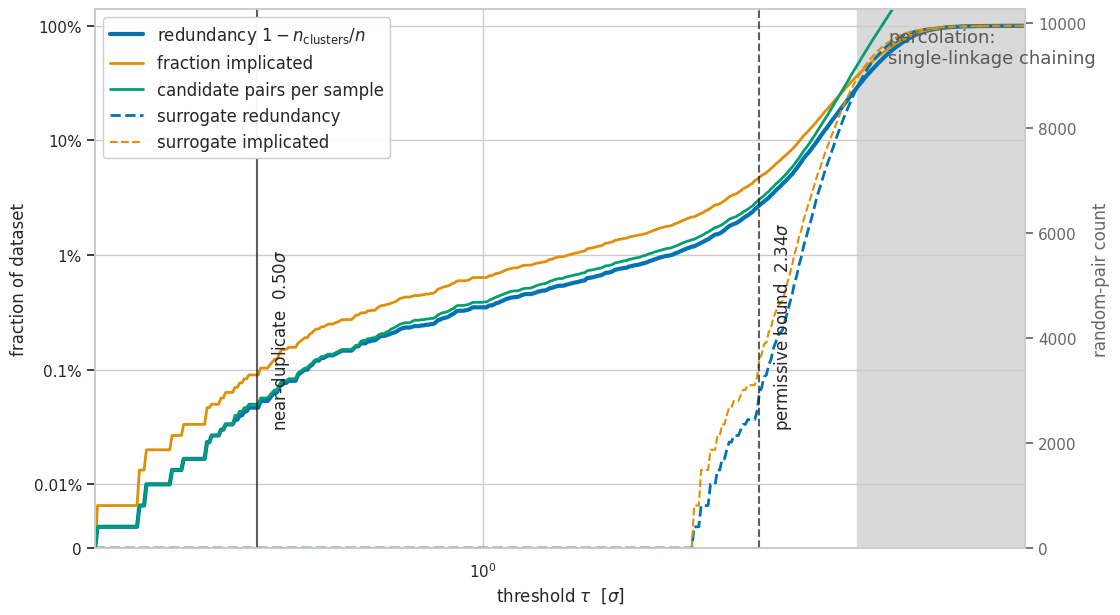

In [23]:
palette = sns.color_palette("colorblind")
figure, axis = plt.subplots(figsize=(12, 7))

if percolating.any():
    axis.axvspan(grid[percolating.argmax()], grid[-1], color="0.85", zorder=0)
    axis.text(grid[percolating.argmax()] * 1.1, 0.95, "percolation:\nsingle-linkage chaining",
              fontsize=13, va="top", color="0.35")

axis.plot(grid, real_redundancy, color=palette[0], lw=3, label="redundancy $1 - n_\\mathrm{clusters}/n$")
axis.plot(grid, real_touched, color=palette[1], lw=2, label="fraction implicated")
axis.plot(grid, real_pairs, color=palette[2], lw=2, label="candidate pairs per sample")
axis.plot(grid, surrogate_redundancy, color=palette[0], lw=2, ls="--", label="surrogate redundancy")
axis.plot(grid, surrogate_touched, color=palette[1], lw=1.5, ls="--", label="surrogate implicated")

rug = axis.twinx()
rug.hist(null_scores, bins=np.logspace(np.log10(tau_low), np.log10(null_scores.max()), 120),
         color=palette[7], alpha=0.35, label="random pairs")
rug.set_ylabel("random-pair count", color="0.4")
rug.tick_params(axis="y", colors="0.4")
rug.grid(False)

for marker, style, text in [(CONFIG["duplicate_sigma"], "-", "near-duplicate"),
                            (min(float(null_scores.min()), tau_high), "--", "permissive bound")]:
    axis.axvline(marker, color="k", ls=style, lw=1.5, alpha=0.7)
    axis.text(marker * 1.04, 3e-4, f"{text}  {marker:.2f}$\\sigma$", fontsize=12, rotation=90,
              va="bottom")

axis.set_xscale("log")
# The whole finding lives below a few percent, so a linear y-axis would flatten it onto zero.
axis.set_yscale("symlog", linthresh=1e-4, linscale=0.5)
axis.set_xlim(tau_low, tau_high)
axis.set_ylim(0, 1.4)
axis.set_yticks([0, 1e-4, 1e-3, 1e-2, 1e-1, 1])
axis.set_yticklabels(["0", "0.01%", "0.1%", "1%", "10%", "100%"])
axis.set_xlabel(r"threshold $\tau$  [$\sigma$]")
axis.set_ylabel("fraction of dataset")
axis.legend(loc="upper left", fontsize=12, framealpha=0.95)
axis.set_zorder(rug.get_zorder() + 1)
axis.patch.set_visible(False)

plt.savefig("context_similarity_sweep.pdf", bbox_inches="tight", pad_inches=0)
pass

## Choosing a threshold

A genuine plateau would mean the data separates into duplicates and non-duplicates with a gap in
between, making the exact choice of $\tau$ within the gap irrelevant. Detecting one needs both an
absolute and a relative tolerance: a stretch over which redundancy moves by less than one percentage
point is meaningless if the redundancy is only a fraction of a percent to begin with — every
sufficiently flat-looking stretch would qualify. Require the redundancy to change by less than 1 pp
*and* by less than 25 % of its own value across the stretch.

Failing that, the curve climbs smoothly and no threshold is intrinsically special. Two nulls bound
how permissive $\tau$ may get:

- **Surrogate control** — the largest $\tau$ at which the phase-randomised surrogate still yields at
  most 0.1 % redundancy. Below it, measured redundancy cannot be attributed to the ambient
  self-similarity of this signal class.
- **Random-pair control** — $\tau$ must stay below the smallest score observed over 100 000 random
  pairs, beyond which it admits distances that demonstrably occur between unrelated samples.

Both are only *upper* bounds, and weak ones: the minimum over 100 000 random pairs is an extreme
order statistic, so it lands far above where duplicates actually live. The manual validation below
confirms this — pairs at the bounding threshold are broadly similar but plainly not duplicates.

So the headline threshold is the stricter, directly interpretable one: the score is a 95th-percentile
per-channel deviation in units of the pooled channel standard deviation, so
$\tau = 0.5\,\sigma$ means *in every one of the 72 channels, 95 % of frames agree to within half a
standard deviation*. That is a convention, stated as such — but it is one whose meaning can be read
off the metric definition, and the closest-pairs figure below shows it is where duplicate character
actually lives. Both thresholds are carried through the table and the summary.

In [24]:
FALSE_MERGE_BUDGET = 0.001
PLATEAU_RELATIVE_TOLERANCE = 0.25

interpretable = ~percolating
log_grid = np.log10(grid)


def is_flat(start, end):
    absolute = real_redundancy[end] - real_redundancy[start]
    relative = absolute / max(real_redundancy[end], 1e-12)
    return absolute <= 0.01 and relative <= PLATEAU_RELATIVE_TOLERANCE


best = None
if interpretable.any():
    limit = int(np.argmax(~interpretable)) if (~interpretable).any() else len(grid)
    start = 0
    for end in range(1, limit):
        if not is_flat(start, end):
            start = end
        elif best is None or log_grid[end] - log_grid[start] > best[1] - best[0]:
            best = (log_grid[start], log_grid[end])

random_floor = float(null_scores.min())
surrogate_ceiling = float(grid[interpretable & (surrogate_redundancy <= FALSE_MERGE_BUDGET)].max())

if best is not None and best[1] - best[0] > 0.3:
    regime = "plateau"
    tau = float(10 ** ((best[0] + best[1]) / 2))
    tau_permissive = tau
    print(f"Plateau spanning {10 ** best[0]:.3f} - {10 ** best[1]:.3f} sigma "
          f"({best[1] - best[0]:.2f} decades); using its midpoint.")
else:
    regime = "smooth climb (no plateau)"
    tau_permissive = min(surrogate_ceiling, random_floor)
    tau = CONFIG["duplicate_sigma"]
    print("No plateau: redundancy rises steadily rather than separating into a duplicate mode and a "
          "non-duplicate mode, so no single tau is intrinsically special.\n")
    print("Upper bounds on tau:")
    print(f"  surrogate stays below {FALSE_MERGE_BUDGET:.1%} redundancy up to {surrogate_ceiling:.3f} sigma")
    print(f"  closest of {len(null_scores)} random pairs sits at         {random_floor:.3f} sigma")
    print(f"  -> most permissive defensible threshold:                  {tau_permissive:.3f} sigma")
    print(f"\nHeadline threshold (interpretable convention):             {tau:.3f} sigma")

print(f"\nRegime: {regime}\ntau (near-duplicate)   = {tau:.4f} sigma")
print(f"tau (most permissive) = {tau_permissive:.4f} sigma")

No plateau: redundancy rises steadily rather than separating into a duplicate mode and a non-duplicate mode, so no single tau is intrinsically special.

Upper bounds on tau:
  surrogate stays below 0.1% redundancy up to 2.393 sigma
  closest of 99996 random pairs sits at         2.338 sigma
  -> most permissive defensible threshold:                  2.338 sigma

Headline threshold (interpretable convention):             0.500 sigma

Regime: smooth climb (no plateau)
tau (near-duplicate)   = 0.5000 sigma
tau (most permissive) = 2.3380 sigma


In [25]:
def summarize_at(threshold):
    below = edges_w <= threshold
    position = np.searchsorted(curve.tau.to_numpy(), threshold, side="right") - 1
    if position < 0:
        components, touched, largest = n, 0, 1
    else:
        row = curve.iloc[position]
        components, touched, largest = int(row.n_components), int(row.n_touched), int(row.max_component)
    surrogate_position = np.searchsorted(surrogate_curve.tau.to_numpy(), threshold, side="right") - 1
    surrogate_components = (
        int(surrogate_curve.n_components.iloc[surrogate_position]) if surrogate_position >= 0 else n
    )
    return {
        "tau": threshold,
        "pairs below": int(below.sum()),
        "effective n": components,
        "redundancy": 1 - components / n,
        "implicated": touched / n,
        "largest cluster": largest,
        "surrogate redundancy": 1 - surrogate_components / n,
    }


quoted = {
    "closest pair in the dataset": float(edges_w.min()),
    "near-duplicate (headline)": tau,
    "1st pct of same-sequence pairs": float(np.percentile(repeat_scores, 1)),
    "surrogate false-merge ceiling": surrogate_ceiling,
    "closest random pair": random_floor,
    "percolation onset": float(grid[percolating].min()) if percolating.any() else float(grid[-1]),
}
threshold_table = pd.DataFrame(
    [{"criterion": label, **summarize_at(value)} for label, value in quoted.items()]
).sort_values("tau").reset_index(drop=True)
threshold_table

,criterion,tau,pairs below,effective n,redundancy,implicated,largest cluster,surrogate redundancy
0,closest pair in the dataset,0.303823,1,29999,0.000033,0.000067,2,0.000000
1,near-duplicate (headline),0.500000,15,29986,0.000467,0.000900,3,0.000000
2,1st pct of same-sequence pairs,0.870878,88,29921,0.002633,0.004900,4,0.000000
3,closest random pair,2.338025,909,29194,0.026867,0.047233,9,0.000567
4,surrogate false-merge ceiling,2.392702,1036,29086,0.030467,0.052467,20,0.000900
5,percolation onset,3.164158,13705,21247,0.291767,0.368700,3383,0.292600


## Candidate recall

The candidate stage only ever re-scores each sample's top `knn_k` neighbours *in embedding
distance*, while the threshold is applied to the refined score. The two orderings are not
identical, so in principle a pair could sit outside both samples' top-`knn_k` neighbourhoods and
still score below $\tau$ — and it would then be invisible to every number above.

Two arguments say this should be rare, and neither of them is worth trusting. A pair enters the
table if *either* endpoint lists the other, which doubles the reach; and a sample's list can only
crowd a genuine duplicate out if the list is already full of them, which the sweep shows it is not.
But neither argument bounds the *metric mismatch*, which is the actual mechanism. So measure it:
score a random set of anchors against **every** other series, with no candidate generation at all,
and count how many of their true below-$\tau$ pairs the candidate table actually contains.

In [26]:
def pair_keys(left, right):
    "Order-independent int64 key per pair, for set arithmetic on pairs."
    return np.minimum(left, right).astype(np.int64) * n + np.maximum(left, right)


anchors = rng.choice(n, CONFIG["n_recall_anchors"], replace=False)
anchor_column = np.repeat(anchors, n - 1)
partner_column = np.concatenate([np.delete(np.arange(n), anchor) for anchor in anchors])
exhaustive = refine(anchor_column, partner_column, series)
table_keys = pair_keys(pairs.i.to_numpy(), pairs.j.to_numpy())

all_pairs = n * (n - 1) / 2
print(f"Exhaustive scan: {len(anchors)} anchors x {n - 1} partners = {anchor_column.size:,} pairs "
      f"({anchor_column.size / all_pairs:.1%} of the {all_pairs:,.0f} pairs in the dataset).\n")

missed = {}
for label, threshold in [("near-duplicate", tau), ("permissive", tau_permissive)]:
    below = exhaustive <= threshold
    present = np.isin(pair_keys(anchor_column[below], partner_column[below]), table_keys)
    total = int(below.sum())
    verdict = f"recall {present.mean():.0%}" if total else "too few to measure"
    print(f"{label} tau = {threshold:.4f}: {total} below-tau pairs truly exist among these anchors, "
          f"{int(present.sum())} of them are in the candidate table -> {verdict}")
    missed[label] = list(zip(anchor_column[below][~present], partner_column[below][~present],
                             exhaustive[below][~present]))

Exhaustive scan: 300 anchors x 29999 partners = 8,999,700 pairs (2.0% of the 449,985,000 pairs in the dataset).

near-duplicate tau = 0.5000: 1 below-tau pairs truly exist among these anchors, 1 of them are in the candidate table -> recall 100%
permissive tau = 2.3380: 30 below-tau pairs truly exist among these anchors, 23 of them are in the candidate table -> recall 77%


Whatever was missed, the question is whether a larger `knn_k` would have caught it. Ask how deep
into each sample's embedding ranking the partner actually sits.

In [27]:
def embedding_ranks(subject_pairs):
    "Rank of each partner in the other's full embedding-distance ordering, both directions."
    tensor = torch.from_numpy(embedding).to(device)
    square_norm = (tensor**2).sum(1)
    result = []
    for left, right in subject_pairs:
        ranks = []
        for anchor, other in ((left, right), (right, left)):
            d2 = square_norm[anchor] + square_norm - 2 * (tensor[anchor] @ tensor.T)
            d2[anchor] = float("inf")
            ranks.append(int((d2 < d2[other]).sum().item()) + 1)
        result.append(tuple(ranks))
    return result


for label, entries in missed.items():
    if not entries:
        continue
    print(f"Pairs missed at the {label} threshold, and where they sit in embedding rank:")
    ranks = embedding_ranks([(a, b) for a, b, _ in entries])
    for (a, b, score), (rank_ab, rank_ba) in zip(entries, ranks):
        print(f"  {a:>6}/{b:<6} at {score:.3f} sigma: embedding rank {rank_ab:,} / {rank_ba:,}")
    reach = max(min(pair) for pair in ranks)
    print(f"  -> knn_k would need to be {reach:,} ({reach / n:.1%} of the dataset) to catch them "
          f"all; it is {CONFIG['knn_k']}.\n")

Pairs missed at the permissive threshold, and where they sit in embedding rank:


    1286/20894  at 2.330 sigma: embedding rank 35 / 50
    9566/27541  at 2.300 sigma: embedding rank 36 / 22
   10167/20982  at 2.300 sigma: embedding rank 293 / 635
   21902/8539   at 1.745 sigma: embedding rank 544 / 4,322
   25560/13199  at 2.221 sigma: embedding rank 96 / 62
   25560/15964  at 2.081 sigma: embedding rank 83 / 215
   21601/9447   at 2.337 sigma: embedding rank 67 / 839
  -> knn_k would need to be 544 (1.8% of the dataset) to catch them all; it is 20.



### What this means

**The candidate stage does lose pairs, and at the permissive threshold the loss is not negligible.**
Crowding is not the cause — no sample's 20 slots are filled with below-$\tau$ neighbours. The cause
is metric mismatch: the embedding distance sums squared deviations over all 23 040 dimensions using
each series' *own* per-channel scale, whereas the score takes a 0.95-quantile over time and then the
single worst channel, using the *pair's* pooled scale. A pair can therefore sit tens to thousands of
places down the embedding ranking and still score below the permissive threshold, which is exactly
what the ranks above show — and the deepest of them decides how large `knn_k` would have to be.

Three consequences, in order of how much they matter:

1. Every redundancy figure in this notebook is a **lower bound**, and at the permissive threshold
   that bound is measurably loose. Read $2.7\,\%$ as "at least $2.7\,\%$".
2. At the headline $\tau = 0.5\,\sigma$ the scan is nearly vacuous in the other direction:
   below-$\tau$ pairs are so rare that covering 2 % of all pairs turns up barely any, so the recall
   printed for it rests on a single-digit sample and should not be read as a tight guarantee. What
   the scan does show is that every pair it missed scored far above $0.5\,\sigma$. Two trajectories
   agreeing to half a pooled standard deviation across 95 % of frames in *all* 72 channels cannot be
   distant in the embedding either, so the headline figure is the one least exposed to this
   limitation, and the one to quote.
3. Closing the gap properly means scoring all $\binom{n}{2} \approx 4.5 \times 10^8$ pairs — about
   an hour on this GPU — rather than nudging `knn_k`, since a `knn_k` large enough to be safe is
   already a sizeable fraction of the dataset per candidate list.

## Manual validation of the threshold

Two checks, and they answer different questions.

**Is the metric right?** Plot the closest pairs in the whole dataset. If the metric works, these must
be visually indistinguishable trajectories. If they are not, nothing downstream means anything.

**Is the threshold right?** Plot 20 pairs just below $\tau$ and 20 just above. Disagreement on more
than about two pairs means the threshold is misplaced — but only if the first check passed.
Separating the two matters: a failure of the first is a broken metric, a failure of the second is a
mis-set knob.

With 72 channels, plotting all of them is unreadable, so each panel shows a fixed representative
subset — the root joint, one ankle, one wrist, and the head, x-axis only — chosen once and applied
to every pair. Solid is the first series, dashed the second.

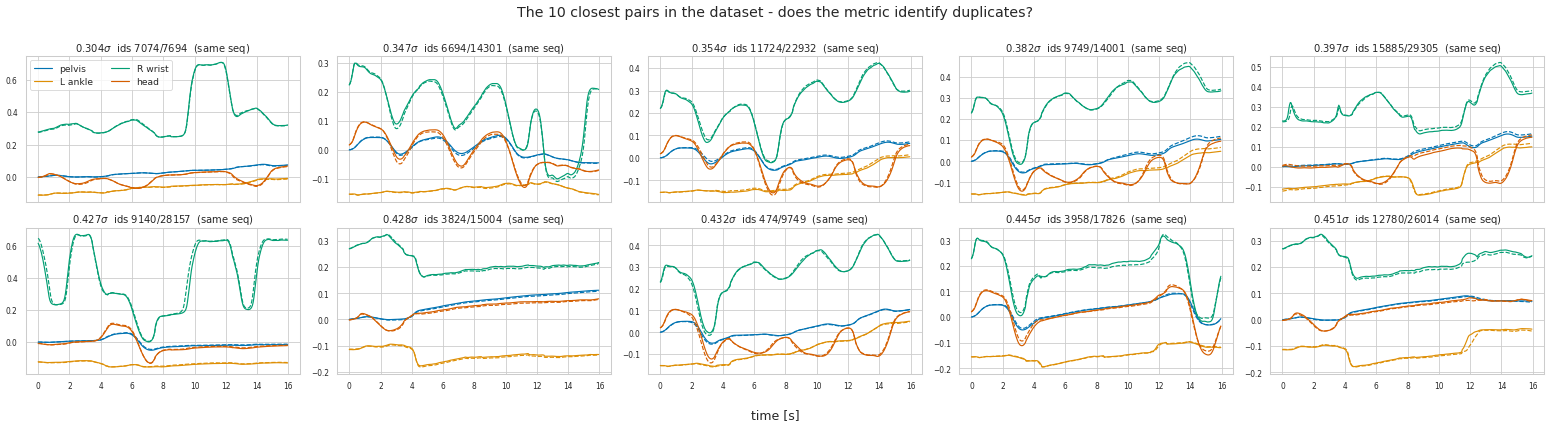

In [28]:
SHOWN_JOINTS = {"pelvis": 0, "L ankle": 7, "R wrist": 21, "head": 15}
SHOWN_CHANNELS = {name: joint * 3 for name, joint in SHOWN_JOINTS.items()}  # x axis of each
time_axis = np.arange(n_time) / 20.0


def plot_pairs(edge_indices, title, filename, columns=5):
    rows = int(np.ceil(len(edge_indices) / columns))
    figure, axes = plt.subplots(rows, columns, figsize=(5.2 * columns, 3.5 * rows),
                                sharex=True, squeeze=False)
    figure.set_dpi(60)  # these grids are wide; the saved PDF stays vector, this only shrinks the
    #                     inline raster so the committed notebook does not balloon
    for panel, edge in enumerate(edge_indices):
        axis = axes.ravel()[panel]
        a, b, weight = edges_i[edge], edges_j[edge], edges_w[edge]
        for color, (name, channel) in enumerate(SHOWN_CHANNELS.items()):
            axis.plot(time_axis, series[a][:, channel], color=palette[color], lw=1.4,
                      label=name if panel == 0 else None)
            axis.plot(time_axis, series[b][:, channel], color=palette[color], lw=1.4, ls="--")
        same = "same seq" if action_sequences[a] == action_sequences[b] else "diff seq"
        axis.set_title(f"{weight:.3f}$\\sigma$  ids {ids[a]}/{ids[b]}  ({same})", fontsize=12)
        axis.tick_params(labelsize=9)
    for panel in range(len(edge_indices), rows * columns):
        axes.ravel()[panel].set_visible(False)
    axes.ravel()[0].legend(fontsize=11, ncol=2)
    figure.suptitle(title, fontsize=17, y=1.0)
    figure.supxlabel("time [s]", fontsize=15)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight", pad_inches=0)
    return figure


closest = np.argsort(edges_w)[:10]
plot_pairs(closest, "The 10 closest pairs in the dataset - does the metric identify duplicates?",
           "context_similarity_closest_pairs.pdf")
pass

15 pairs just below tau = 0.500, 20 just above.


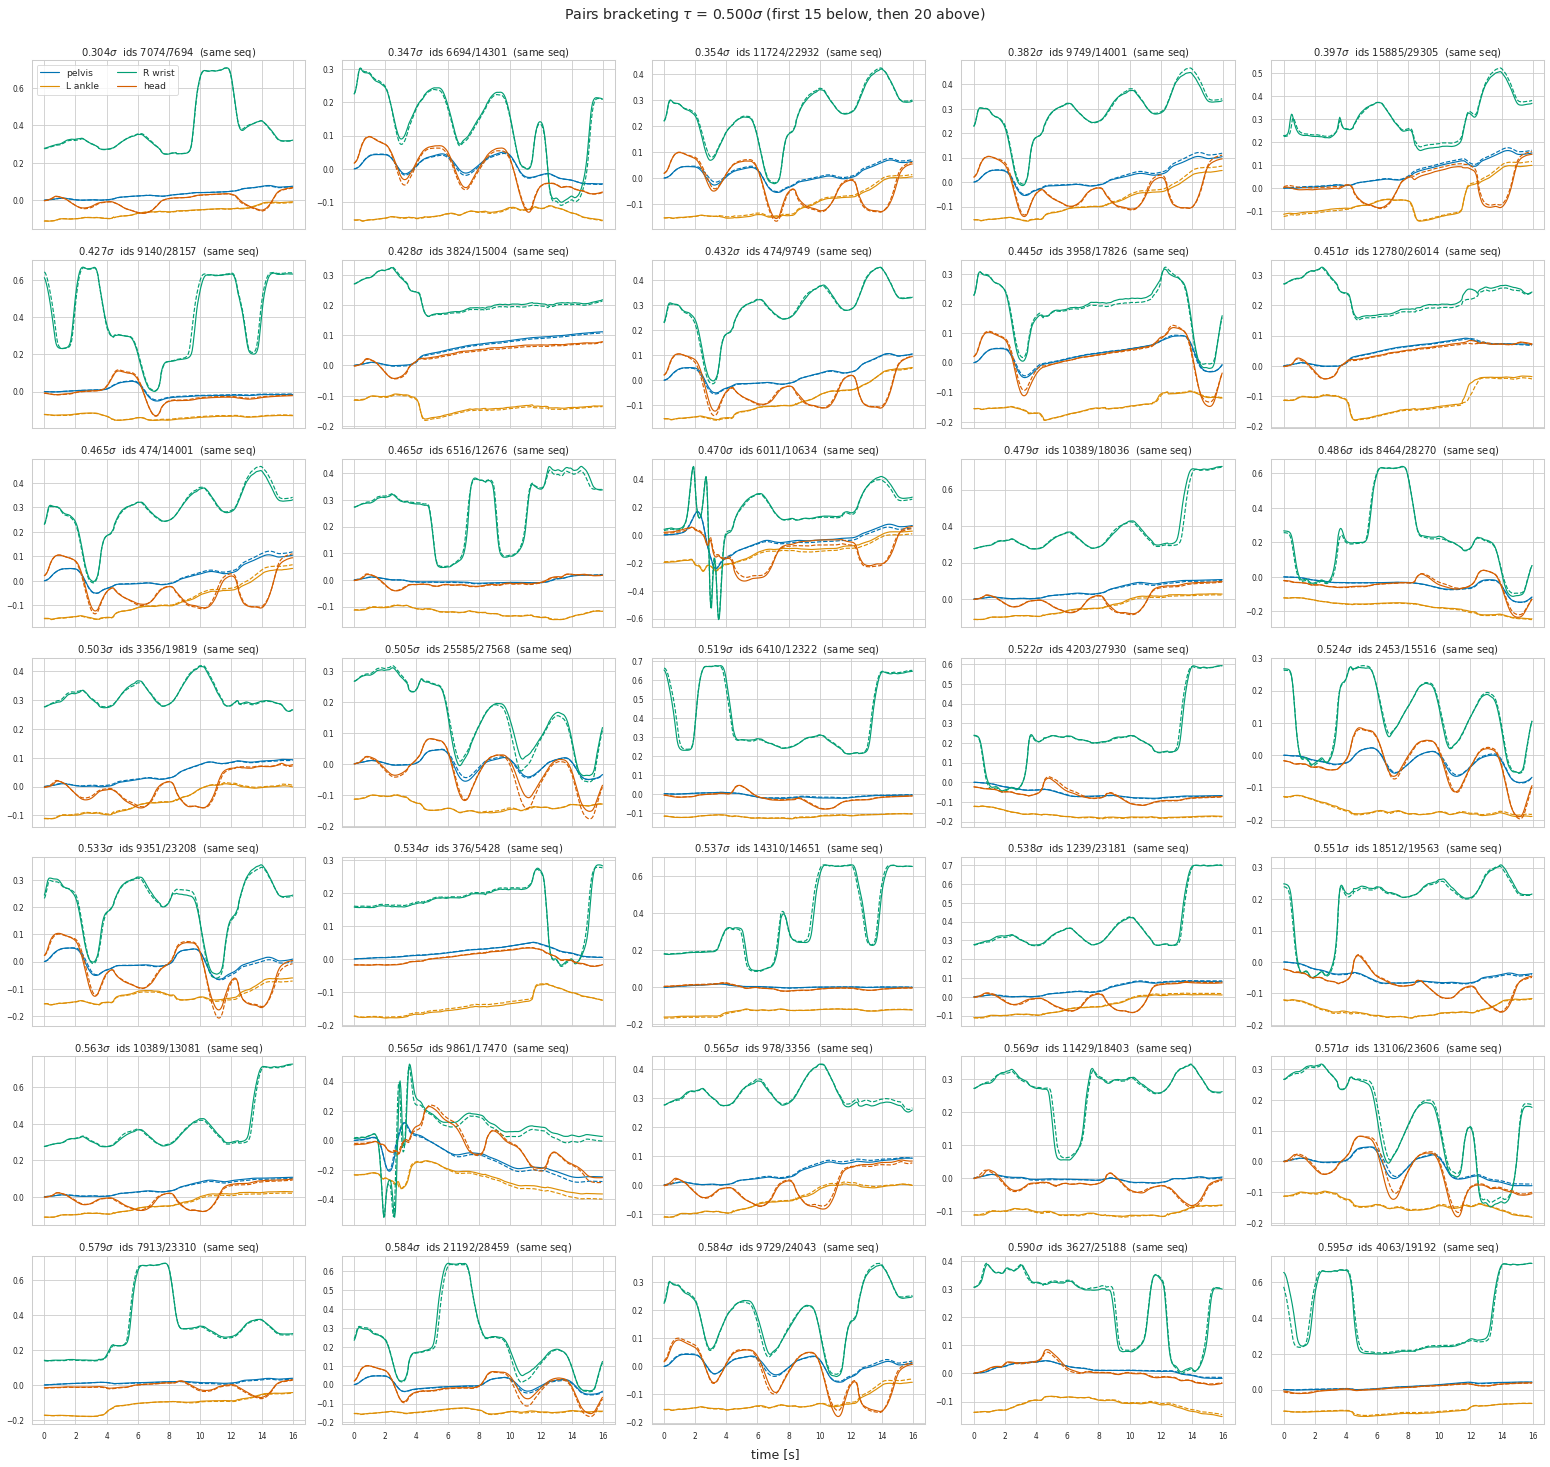

In [29]:
order = np.argsort(edges_w)
below_index = order[edges_w[order] <= tau][-20:]
above_index = order[edges_w[order] > tau][:20]
print(f"{len(below_index)} pairs just below tau = {tau:.3f}, {len(above_index)} just above.")

plot_pairs(list(below_index) + list(above_index),
           f"Pairs bracketing $\\tau$ = {tau:.3f}$\\sigma$ "
           f"(first {len(below_index)} below, then {len(above_index)} above)",
           "context_similarity_validation_pairs.pdf")
pass

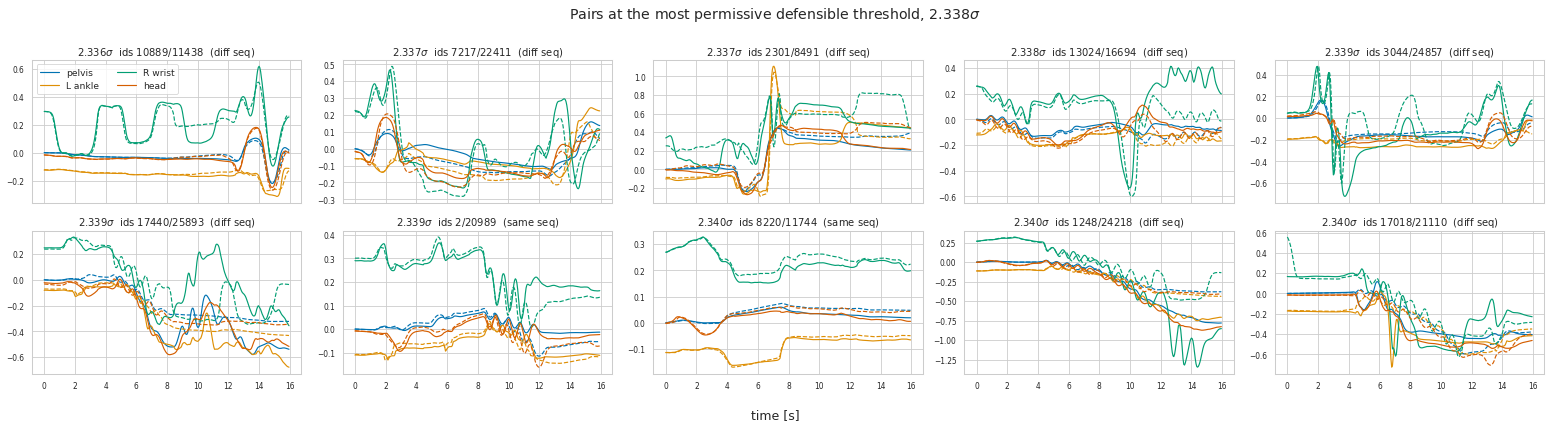

In [30]:
bracket = np.argsort(np.abs(edges_w - tau_permissive))[:10]
plot_pairs(bracket[np.argsort(edges_w[bracket])],
           f"Pairs at the most permissive defensible threshold, {tau_permissive:.3f}$\\sigma$",
           "context_similarity_permissive_pairs.pdf")
pass

### Verdict

**The metric is sound; the loose threshold is not a duplicate threshold.**

*Closest pairs* — all ten lie essentially on top of each other in every plotted channel, and all ten
share an identical 4-action sequence. The metric does identify duplicates, so the machinery
downstream is trustworthy. This is the check that had to pass.

*Bracketing $\tau = 0.5\,\sigma$* — pairs below are visually near-identical; pairs above start to
show visible per-channel divergence. The boundary is not razor-sharp, which is exactly what "no
plateau" means, but it lands where duplicate character stops.

*At the permissive bound, $2.33\,\sigma$* — these pairs are **not** duplicates. They share an overall
motion envelope, and essentially all of them share an action sequence, but individual channels
diverge plainly. This is the observation that demoted the two null-based criteria from "threshold
selectors" to "upper bounds": the minimum over 100 000 random pairs is an extreme order statistic,
and it sits far above where duplication actually ends. Reporting 2.6 % redundancy without looking at
these panels would have been wrong.

Both numbers are therefore carried forward, and they mean different things: $0.5\,\sigma$ measures
near-duplicate trajectories, $2.33\,\sigma$ measures samples that are merely similar — almost always
because they were generated from the same prompt.

## Chaining check

Single linkage merges transitively, so one bad edge can fuse two unrelated groups. If the cluster
size distribution at $\tau$ is top-heavy — a few very large clusters rather than many small ones —
the redundancy number is a chaining artefact.

In [31]:
def clusters_at(threshold):
    "Connected components of the candidate graph restricted to edges at or below the threshold."
    below = edges_w <= threshold
    graph = csr_matrix(
        (np.ones(int(below.sum())), (edges_i[below], edges_j[below])), shape=(n, n)
    )
    _, labels = connected_components(graph, directed=False)
    return labels


labels_at_tau = clusters_at(tau)
# Cross-check against the independent MST/union-find walk that produced the sweep curve.
assert int(pd.Series(labels_at_tau).value_counts().max()) == summarize_at(tau)["largest cluster"]
sizes = pd.Series(labels_at_tau).value_counts()
non_trivial = sizes[sizes > 1]

print(f"Clusters of size > 1 at tau = {tau:.4f}: {len(non_trivial)}")
print(f"Samples in them: {int(non_trivial.sum())} ({non_trivial.sum() / n:.2%} of the dataset)")
print(f"Largest cluster: {int(sizes.max())} samples")
print("\nCluster size distribution:")
print(non_trivial.value_counts().sort_index().rename("number of clusters").to_string())

Clusters of size > 1 at tau = 0.5000: 13
Samples in them: 27 (0.09% of the dataset)
Largest cluster: 3 samples

Cluster size distribution:
count
2    12
3     1


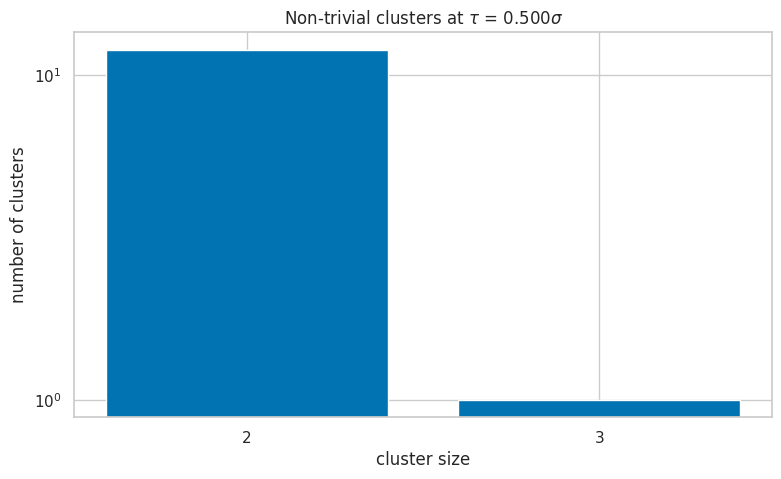

In [32]:
figure, axis = plt.subplots(figsize=(9, 5))
if len(non_trivial):
    counts = non_trivial.value_counts().sort_index()
    axis.bar(counts.index.astype(str), counts.to_numpy(), color=palette[0])
    axis.set_yscale("log")
axis.set_xlabel("cluster size")
axis.set_ylabel("number of clusters")
axis.set_title(f"Non-trivial clusters at $\\tau$ = {tau:.3f}$\\sigma$")
plt.savefig("context_similarity_cluster_sizes.pdf", bbox_inches="tight", pad_inches=0)
pass

## Action-sequence duplication

The label-level analysis, which is independent of everything above. Each sample is generated from an
ordered 4-tuple of actions drawn from a 19-word vocabulary, so at most $19^4 = 130\,321$ distinct
sequences exist for 30 000 samples and collisions are guaranteed by construction.

Two baselines matter. Under **i.i.d. uniform** draws the expected number of distinct sequences
follows the standard occupancy formula. But the generator does not draw i.i.d.: `sample_actions` is
called with `more_similar_actions=True`, which first draws a small pool and then samples the four
actions from that pool, deliberately inflating repeats *within* a sequence. Both numbers are
reported so the excess over i.i.d. is not mistaken for a bug.

Exact string equality is the right notion of "same action" here: `is_synonymous` groups actions by
the comma-separated rows of `list_of_actions.txt`, and every row in the shipped file holds exactly
one action, so it can never fire.

In [33]:
VOCAB_SIZE = 19
SEQUENCE_LENGTH = 4
space = VOCAB_SIZE**SEQUENCE_LENGTH

distinct = len(sequence_groups)
expected_distinct = space * (1 - (1 - 1 / space) ** n)
colliding_groups = {seq: rows for seq, rows in sequence_groups.items() if len(rows) > 1}

vocabulary = sorted({action for sequence in action_sequences for action in sequence})
assert len(vocabulary) == VOCAB_SIZE, len(vocabulary)
assert all(len(sequence) == SEQUENCE_LENGTH for sequence in action_sequences)

print(f"Sequence space:                19^4 = {space}")
print(f"Distinct sequences observed:   {distinct} of {n} samples")
print(f"Expected under i.i.d. uniform: {expected_distinct:.0f}")
print(f"Excess collisions over i.i.d.: {expected_distinct - distinct:.0f}")
print(f"\nColliding groups: {len(colliding_groups)}, "
      f"covering {sum(len(r) for r in colliding_groups.values())} samples "
      f"({sum(len(r) for r in colliding_groups.values()) / n:.1%})")
print(f"Largest group: {max(len(r) for r in sequence_groups.values())} samples")

within_repeat = np.mean([len(set(s)) < len(s) for s in action_sequences])
iid_within_repeat = 1 - (19 * 18 * 17 * 16) / space
print(f"\nSequences containing a repeated action: {within_repeat:.1%} "
      f"(i.i.d. uniform would give {iid_within_repeat:.1%})")

Sequence space:                19^4 = 130321
Distinct sequences observed:   23772 of 30000 samples
Expected under i.i.d. uniform: 26797
Excess collisions over i.i.d.: 3025

Colliding groups: 4501, covering 10729 samples (35.8%)
Largest group: 8 samples

Sequences containing a repeated action: 67.9% (i.i.d. uniform would give 28.6%)


In [34]:
group_sizes = pd.Series([len(rows) for rows in sequence_groups.values()]).value_counts().sort_index()
group_sizes.index.name = "samples sharing a sequence"
group_sizes.rename("number of sequences").to_frame().T

samples sharing a sequence,1,2,3,4,5,6,7,8
number of sequences,19271,3326,800,256,76,30,11,2


In [35]:
print({split: int((split_of == split).sum()) for split in SPLITS})

cross_split_groups, cross_split_pairs = 0, 0
for rows in colliding_groups.values():
    involved = {split_of[row] for row in rows}
    if len(involved) > 1:
        cross_split_groups += 1
        counts = pd.Series([split_of[row] for row in rows]).value_counts()
        total = int(counts.sum())
        cross_split_pairs += (total * (total - 1) - sum(c * (c - 1) for c in counts)) // 2

print(f"\nAction sequences appearing in more than one split: {cross_split_groups} "
      f"of {len(colliding_groups)} colliding groups")
print(f"Cross-split pairs sharing an action sequence: {cross_split_pairs}")

test_train_leak = sum(
    1 for rows in colliding_groups.values()
    if {"test"} & {split_of[r] for r in rows} and {"train"} & {split_of[r] for r in rows}
)
print(f"Sequences present in both train and test: {test_train_leak}")

{'train': 24000, 'val': 3000, 'test': 3000}



Action sequences appearing in more than one split: 1735 of 4501 colliding groups
Cross-split pairs sharing an action sequence: 2955
Sequences present in both train and test: 888


### Where the two analyses meet

Cross-tabulating signal-level and label-level duplication answers whether near-duplicate
trajectories are the ones generated from the same prompt.

In [36]:
sequence_id = {sequence: index for index, sequence in enumerate(sequence_groups)}
sequence_of = np.array([sequence_id[sequence] for sequence in action_sequences])

base_rate = float(np.mean(
    sequence_of[rng.integers(0, n, 200_000)] == sequence_of[rng.integers(0, n, 200_000)]
))
print(f"Base rate: two random samples share an action sequence {base_rate:.4%} of the time.\n")

for label, threshold in [("near-duplicate", tau), ("permissive", tau_permissive)]:
    selected = edges_w <= threshold
    shared = sequence_of[edges_i[selected]] == sequence_of[edges_j[selected]]
    print(f"{label} tau = {threshold:.4f}: {int(selected.sum())} signal-duplicate pairs")
    if selected.any():
        print(f"    share an action sequence: {int(shared.sum())} ({shared.mean():.1%}), "
              f"enrichment {shared.mean() / max(base_rate, 1e-12):,.0f}x over chance")
    print(f"    same-sequence pairs scoring below it: {(repeat_scores <= threshold).sum()} "
          f"of {len(repeat_scores)} ({(repeat_scores <= threshold).mean():.2%})")

Base rate: two random samples share an action sequence 0.0035% of the time.

near-duplicate tau = 0.5000: 15 signal-duplicate pairs
    share an action sequence: 15 (100.0%), enrichment 28,571x over chance
    same-sequence pairs scoring below it: 15 of 8759 (0.17%)
permissive tau = 2.3380: 909 signal-duplicate pairs
    share an action sequence: 580 (63.8%), enrichment 18,230x over chance
    same-sequence pairs scoring below it: 656 of 8759 (7.49%)


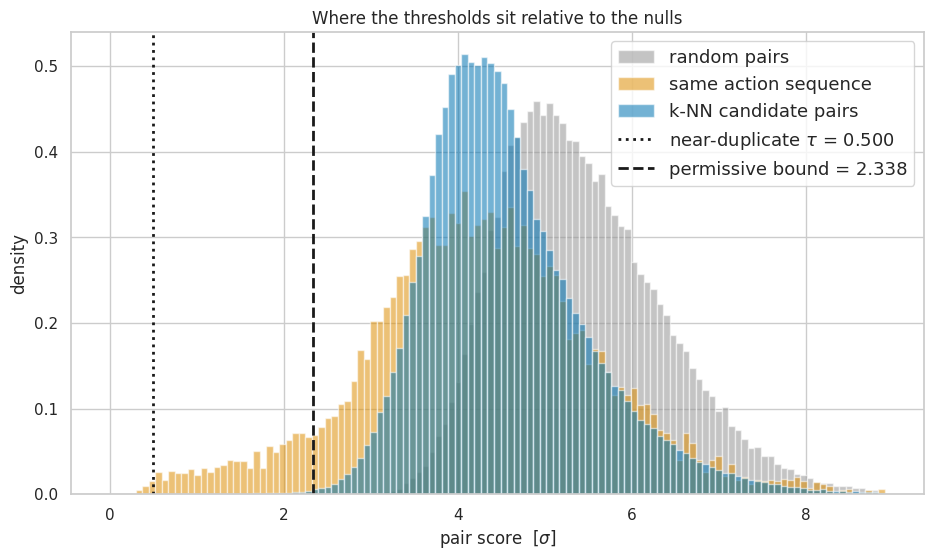

In [37]:
figure, axis = plt.subplots(figsize=(11, 6))
bins = np.linspace(0, max(np.percentile(null_scores, 99.5), np.percentile(repeat_scores, 99.5)), 120)
axis.hist(null_scores, bins=bins, density=True, alpha=0.55, color=palette[7], label="random pairs")
axis.hist(repeat_scores, bins=bins, density=True, alpha=0.55, color=palette[1],
          label="same action sequence")
axis.hist(edges_w, bins=bins, density=True, alpha=0.55, color=palette[0], label="k-NN candidate pairs")
axis.axvline(tau, color="k", ls=":", lw=2, label=f"near-duplicate $\\tau$ = {tau:.3f}")
axis.axvline(tau_permissive, color="k", ls="--", lw=2,
             label=f"permissive bound = {tau_permissive:.3f}")
axis.set_xlabel(r"pair score  [$\sigma$]")
axis.set_ylabel("density")
axis.set_title("Where the thresholds sit relative to the nulls")
axis.legend(fontsize=13)
plt.savefig("context_similarity_score_distributions.pdf", bbox_inches="tight", pad_inches=0)
pass

## Summary

Redundancy figures are lower bounds — see *Candidate recall* for the measured shortfall.

In [38]:
at_tau = summarize_at(tau)
at_permissive = summarize_at(tau_permissive)
summary = pd.DataFrame([
    ("samples analysed", f"{n}"),
    ("degenerate series excluded", f"{n_degenerate}"),
    ("exact duplicate groups (raw)", f"{len(exact_groups['raw'])}"),
    ("exact duplicate groups (round 4)", f"{len(exact_groups['round(4)'])}"),
    ("regime", regime),
    ("--- near-duplicate threshold ---", ""),
    ("tau [sigma]", f"{tau:.4f}"),
    ("candidate pairs below tau", f"{at_tau['pairs below']}"),
    ("effective dataset size", f"{at_tau['effective n']}"),
    ("signal redundancy", f"{at_tau['redundancy']:.4%}"),
    ("samples implicated", f"{at_tau['implicated']:.4%}"),
    ("largest cluster", f"{at_tau['largest cluster']}"),
    ("surrogate redundancy at same tau", f"{at_tau['surrogate redundancy']:.4%}"),
    ("--- most permissive defensible threshold ---", ""),
    ("tau [sigma]", f"{tau_permissive:.4f}"),
    ("effective dataset size", f"{at_permissive['effective n']}"),
    ("signal redundancy", f"{at_permissive['redundancy']:.4%}"),
    ("surrogate redundancy at same tau", f"{at_permissive['surrogate redundancy']:.4%}"),
    ("--- references ---", ""),
    ("closest pair in the dataset", f"{edges_w.min():.3f}"),
    ("random-pair null, minimum / 1st pct",
     f"{null_scores.min():.3f} / {np.percentile(null_scores, 1):.3f}"),
    ("same-sequence pairs, minimum / 1st pct",
     f"{repeat_scores.min():.3f} / {np.percentile(repeat_scores, 1):.3f}"),
    ("distinct action sequences", f"{distinct} of {n}"),
    ("action-sequence redundancy", f"{1 - distinct / n:.2%}"),
    ("colliding action-sequence groups", f"{len(colliding_groups)}"),
    ("cross-split colliding sequences", f"{cross_split_groups}"),
    ("cross-split pairs sharing a sequence", f"{cross_split_pairs}"),
], columns=["quantity", "value"])
summary

,quantity,value
0,samples analysed,30000
1,degenerate series excluded,0
2,exact duplicate groups (raw),0
3,exact duplicate groups (round 4),0
4,regime,smooth climb (no plateau)
5,--- near-duplicate threshold ---,
6,tau [sigma],0.5000
7,candidate pairs below tau,15
8,effective dataset size,29986
9,signal redundancy,0.0467%


In [39]:
per_split = pd.DataFrame([
    {
        "split": split,
        "samples": int((split_of == split).sum()),
        "distinct sequences": len({action_sequences[k] for k in np.where(split_of == split)[0]}),
        "sequence redundancy": 1 - len({action_sequences[k] for k in np.where(split_of == split)[0]})
        / max(int((split_of == split).sum()), 1),
        "samples in signal clusters": int(pd.Series(labels_at_tau[split_of == split]).map(
            pd.Series(labels_at_tau).value_counts()).gt(1).sum()),
    }
    for split in ["train", "val", "test"]
])
per_split

,split,samples,distinct sequences,sequence redundancy,samples in signal clusters
0,train,24000,19774,0.176083,23
1,val,3000,2905,0.031667,1
2,test,3000,2918,0.027333,3


In [40]:
print(f"Persisted artefacts in {out_dir}:")
for path in sorted(out_dir.iterdir()):
    print(f"  {path.name}  ({path.stat().st_size / 1e6:.1f} MB)")
print("\nFigures (git-ignored, in this directory):")
for name in sorted(Path().glob("context_similarity_*.pdf")):
    print(f"  {name}")

Persisted artefacts in /workspaces/quants-generate/quants/notebooks/similarity:
  pairs.parquet  (7.0 MB)
  sweep_curve.csv  (1.0 MB)
  sweep_curve_surrogate.csv  (1.1 MB)

Figures (git-ignored, in this directory):
  context_similarity_closest_pairs.pdf
  context_similarity_cluster_sizes.pdf
  context_similarity_permissive_pairs.pdf
  context_similarity_score_distributions.pdf
  context_similarity_sweep.pdf
  context_similarity_validation_pairs.pdf
